## Predict a student's placement package (LPA) using academic and skill-related features.


#### Import Libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Load Dataset

In [93]:
data=pd.read_csv("data.csv")
print(data)

      CGPA  DSA_Score  Aptitude_Score  Internships  Projects  Hackathons  \
0     7.19       76.0              39            2       7.0           7   
1     9.78       41.0              37            1       2.0           6   
2     8.79       91.0              99            2       2.0           2   
3     8.19       37.0              38            0       5.0           2   
4     6.20       50.0              98            0       5.0           6   
...    ...        ...             ...          ...       ...         ...   
1025  8.75       58.0              66            0       1.0           6   
1026  8.36       33.0              35            4       9.0           6   
1027  8.60       90.0              62            2       8.0           4   
1028  6.32       53.0              39            0       8.0           6   
1029  9.55       46.0              37            2      10.0           3   

      Certifications  Communication_Score  Package_LPA  
0                  7          

#### Data Understanding

In [94]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CGPA                 1009 non-null   float64
 1   DSA_Score            1009 non-null   float64
 2   Aptitude_Score       1030 non-null   int64  
 3   Internships          1030 non-null   int64  
 4   Projects             1010 non-null   float64
 5   Hackathons           1030 non-null   int64  
 6   Certifications       1030 non-null   int64  
 7   Communication_Score  1010 non-null   float64
 8   Package_LPA          1030 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 72.6 KB
None


In [95]:
print(data.describe())

              CGPA    DSA_Score  Aptitude_Score  Internships     Projects  \
count  1009.000000  1009.000000     1030.000000  1030.000000  1010.000000   
mean      7.710367    63.990089       67.907767     1.988350     5.603960   
std       1.320723    22.126842       18.776064     1.424436     2.856249   
min       5.520000    30.000000       35.000000     0.000000     1.000000   
25%       6.540000    46.000000       52.000000     1.000000     3.000000   
50%       7.740000    62.000000       68.000000     2.000000     6.000000   
75%       8.860000    81.000000       84.000000     3.000000     8.000000   
max      10.000000   220.000000      100.000000     4.000000    10.000000   

        Hackathons  Certifications  Communication_Score  Package_LPA  
count  1030.000000     1030.000000          1010.000000  1030.000000  
mean      3.483495        5.044660            69.489109    17.012903  
std       2.353010        3.105834            17.134065     3.020141  
min       0.000000    

#### Exploratory Data Analysis (EDA) and Data Preprocessing


##### 1. Null Values


In [96]:
print("Initial Total Null Values:",data.isnull().sum().sum())
null_columns=data.columns[data.isnull().any()].tolist()

for i in null_columns :
    data.fillna({i:data[i].mean()},inplace=True)

print("Final Total Null Values:",data.isnull().sum().sum())

Initial Total Null Values: 82
Final Total Null Values: 0


##### 2. Duplicates


In [97]:
print("Total Duplicated Values:",data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Final Duplicated Values:",data.duplicated().sum())

Total Duplicated Values: 30
Final Duplicated Values: 0


##### 3. Outliers


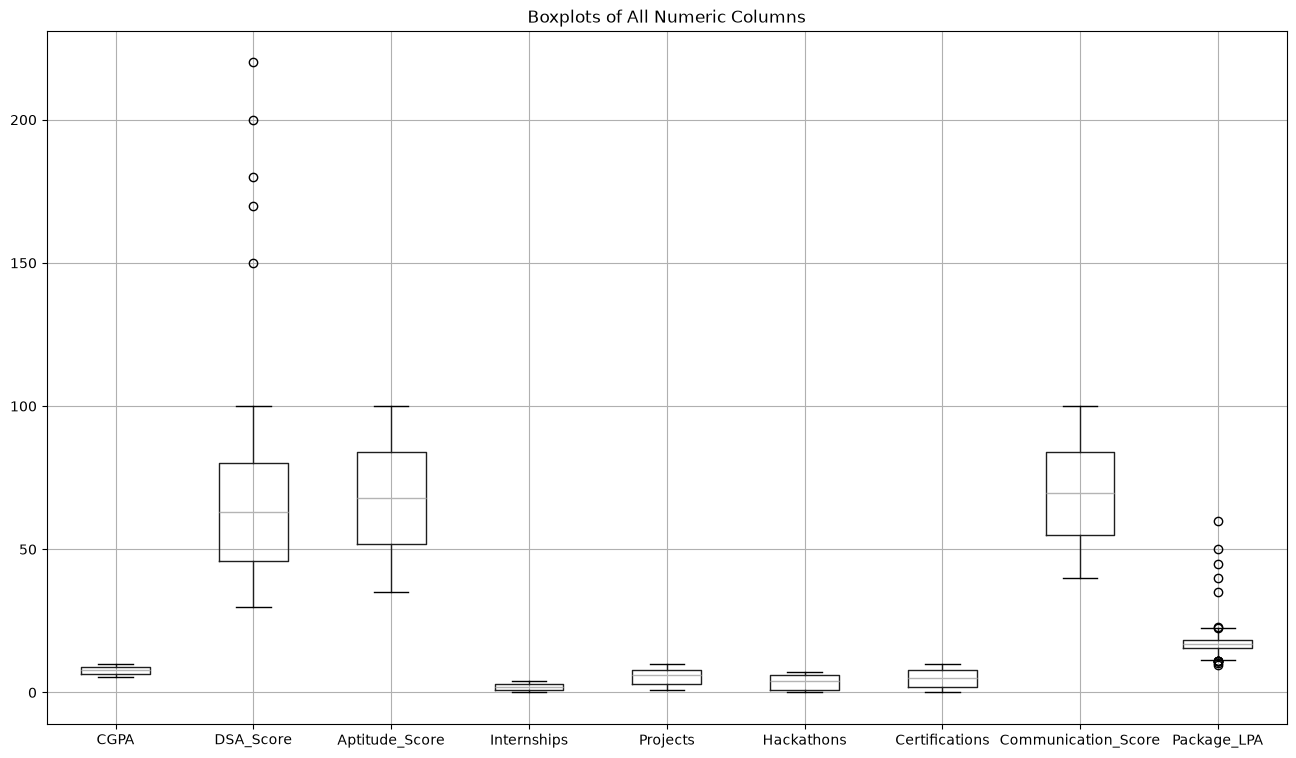

In [98]:
columns=data.select_dtypes(include=["float64","int64"])
columns.boxplot(
    figsize=(16,9),  
)
plt.title("Boxplots of All Numeric Columns")
plt.show()

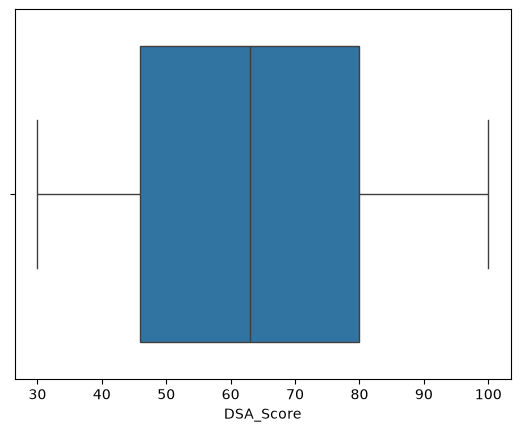

In [99]:
Q1=data["DSA_Score"].quantile(0.25)
Q3=data["DSA_Score"].quantile(0.75)
IQR=Q3-Q1
max_range=Q3+IQR*1.5
min_range=Q1-IQR*1.5

data=data[(data["DSA_Score"]<=max_range) & (data["DSA_Score"]>=min_range)]
sns.boxplot(x=data["DSA_Score"])
plt.show()

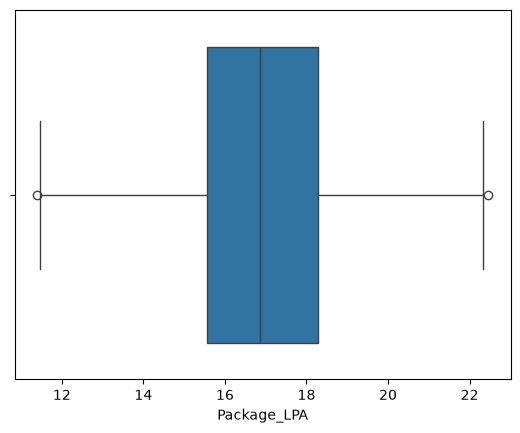

In [100]:
Q1=data["Package_LPA"].quantile(0.25)
Q3=data["Package_LPA"].quantile(0.75)
IQR=Q3-Q1
max_range=Q3+IQR*1.5
min_range=Q1-IQR*1.5

data=data[(data["Package_LPA"]<=max_range) & (data["Package_LPA"]>=min_range)]
sns.boxplot(x=data["Package_LPA"])
plt.show()

#### Feature Selection


In [101]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
x=data.iloc[:,:-1]
y=data["Package_LPA"]
lr=LinearRegression()
sfs=SequentialFeatureSelector(lr,k_features=5,forward=True)
sfs.fit(x,y)
new_column=list(sfs.k_feature_names_)
print(new_column)


['CGPA', 'DSA_Score', 'Aptitude_Score', 'Internships', 'Projects']


#### Train Test Split

In [102]:
from sklearn.model_selection import train_test_split
x=data[new_column]
y=data["Package_LPA"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train)

     CGPA  DSA_Score  Aptitude_Score  Internships  Projects
491  8.29       79.0              72            4       1.0
994  7.12       68.0              61            3       9.0
681  6.66       89.0              35            4      10.0
602  6.30       92.0              85            2       5.0
34   9.85       74.0              80            1       7.0
..    ...        ...             ...          ...       ...
107  8.90       70.0              94            2       3.0
273  9.61       46.0              69            2       2.0
876  8.72       70.0              68            1       3.0
444  9.16       34.0              75            1       6.0
103  7.79       49.0              91            1       8.0

[784 rows x 5 columns]


#### Linear Regression Model


In [111]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
print("Accuracy:",lr.score(x_test,y_test)*100)



Accuracy: 73.15040228803373


#### Ridge Regression Model

In [112]:
from sklearn.linear_model import Ridge
ri=Ridge(alpha=10)
ri.fit(x_train,y_train)
print("Accuracy:",ri.score(x_test,y_test)*100)


Accuracy: 73.10256238192355


#### Lasso Regression Model

In [113]:
from sklearn.linear_model import Lasso
la=Lasso(alpha=10)
la.fit(x_train,y_train)
print("Accuracy:",la.score(x_test,y_test)*100)


Accuracy: 2.0779558140464394


#### Model Comparison


In [119]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
dict={"Models":["Linear","Ridge","Lasso"],
"R Square Value":[lr.score(x_test,y_test)*100,ri.score(x_test,y_test)*100,la.score(x_test,y_test)*100],
"MSE":[mean_squared_error(y_test,lr.predict(x_test)),mean_squared_error(y_test,ri.predict(x_test)),mean_squared_error(y_test,la.predict(x_test))],
"MAE":[mean_absolute_error(y_test,lr.predict(x_test)),mean_absolute_error(y_test,ri.predict(x_test)),mean_absolute_error(y_test,la.predict(x_test))]
}
Model_Comparison=pd.DataFrame(dict)
print(Model_Comparison)
print("Best Model: Linear Regression")

   Models  R Square Value       MSE      MAE
0  Linear       73.150402  1.259628  0.93091
1   Ridge       73.102562  1.261872  0.93146
2   Lasso        2.077956  4.593936  1.77916
Best Model: Linear Regression


#### Deployement

In [118]:
import joblib

joblib.dump(lr, "placement_model.pkl")

['placement_model.pkl']